<a href="https://colab.research.google.com/github/saniya0210/Data_Science_Lab/blob/main/experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (change filename if needed)
df = pd.read_csv("/content/Titanic-Dataset.csv")

# Display first rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
# Remove rows with missing 'Age' values
df_cleaned_age = df.dropna(subset=['Age'])

print("DataFrame info after removing rows with missing 'Age' values:")
display(df_cleaned_age.info())

DataFrame info after removing rows with missing 'Age' values:
<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    object 
 4   Sex          714 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    object 
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    object 
 11  Embarked     712 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.5+ KB


None

In [12]:
print("Descriptive statistics for numerical features:")
display(df_cleaned_age.describe())

print("\nInformation about the DataFrame (including non-null counts and dtypes):")
display(df_cleaned_age.info())

Descriptive statistics for numerical features:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,448.582633,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
std,259.119524,0.491460,0.838250,14.526497,0.929783,0.853289,52.918930
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.250000,0.000000,1.000000,20.125000,0.000000,0.000000,8.050000
50%,445.000000,0.000000,2.000000,28.000000,0.000000,0.000000,15.741700
75%,677.750000,1.000000,3.000000,38.000000,1.000000,1.000000,33.375000
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200



Information about the DataFrame (including non-null counts and dtypes):
<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  714 non-null    int64   
 1   Survived     714 non-null    int64   
 2   Pclass       714 non-null    int64   
 3   Name         714 non-null    object  
 4   Sex          714 non-null    object  
 5   Age          714 non-null    float64 
 6   SibSp        714 non-null    int64   
 7   Parch        714 non-null    int64   
 8   Ticket       714 non-null    object  
 9   Fare         714 non-null    float64 
 10  Cabin        185 non-null    object  
 11  Embarked     712 non-null    object  
 12  AgeGroup     714 non-null    category
dtypes: category(1), float64(2), int64(5), object(5)
memory usage: 73.7+ KB


None

In [13]:
print("\nMissing values count per column:")
display(df_cleaned_age.isnull().sum())


Missing values count per column:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
# Calculate survival rate by age
survival_rate_by_age = df_cleaned_age.groupby('Age')['Survived'].mean().reset_index()

print("Survival rate by age (first 5 rows):")
display(survival_rate_by_age.head())

Survival rate by age (first 5 rows):


,Age,Survived
0,0.42,1.0
1,0.67,1.0
2,0.75,1.0
3,0.83,1.0
4,0.92,1.0


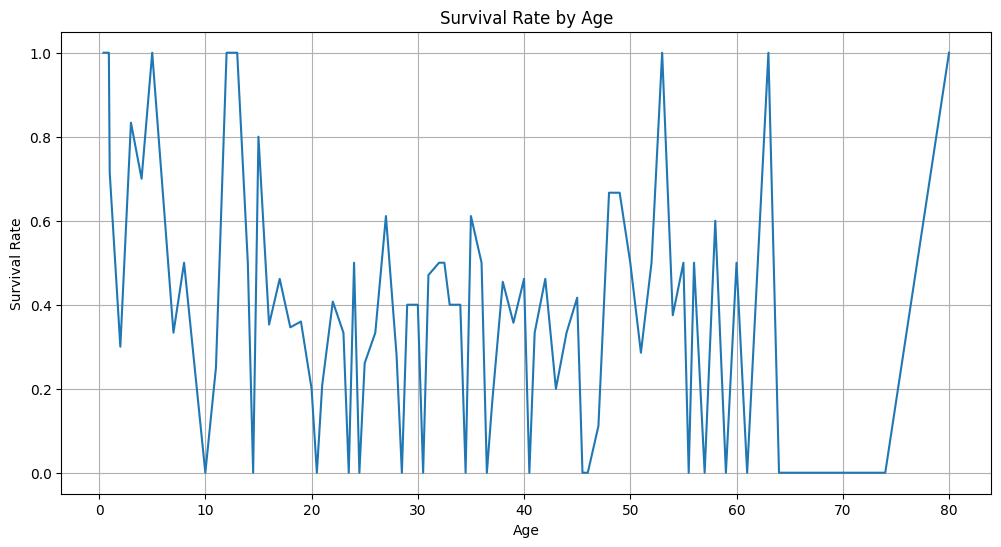

In [8]:
# Plot survival rate vs. age
plt.figure(figsize=(12, 6))
sns.lineplot(x='Age', y='Survived', data=survival_rate_by_age)
plt.title('Survival Rate by Age')
plt.xlabel('Age')
plt.ylabel('Survival Rate')
plt.grid(True)
plt.show()

Survival rate by gender:


,Sex,Survived
0,female,0.754789
1,male,0.205298


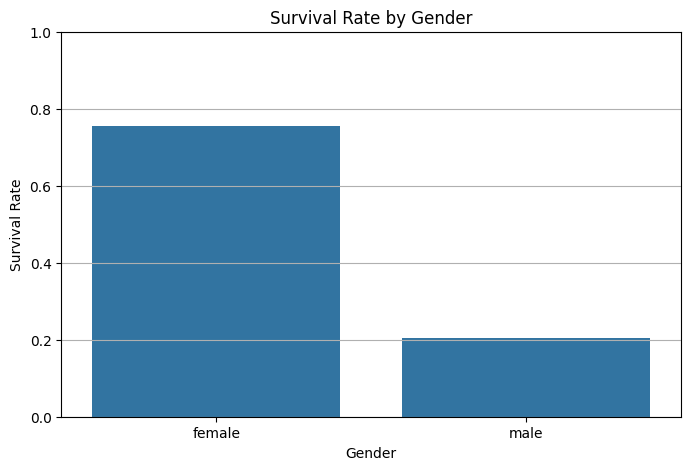

In [9]:
# Calculate survival rate by gender
survival_rate_by_gender = df_cleaned_age.groupby('Sex')['Survived'].mean().reset_index()

print("Survival rate by gender:")
display(survival_rate_by_gender)

# Plot survival rate by gender
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survived', data=survival_rate_by_gender)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.grid(axis='y')
plt.show()

In [ ]:
# Impute missing 'Embarked' values with the mode
most_frequent_embarked = df_cleaned_age['Embarked'].mode()[0]
df_cleaned_age['Embarked'].fillna(most_frequent_embarked, inplace=True)

print("Missing values after imputing 'Embarked':")
display(df_cleaned_age.isnull().sum())

In [ ]:
# Calculate survival rate by Embarked port
survival_rate_by_embarked = df_cleaned_age.groupby('Embarked')['Survived'].mean().reset_index()

print("Survival rate by Embarked port:")
display(survival_rate_by_embarked)

# Plot survival rate by Embarked port
plt.figure(figsize=(8, 5))
sns.barplot(x='Embarked', y='Survived', data=survival_rate_by_embarked)
plt.title('Survival Rate by Embarked Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.grid(axis='y')
plt.show()

Survival rate by passenger class:


,Pclass,Survived
0,1,0.655914
1,2,0.479769
2,3,0.239437


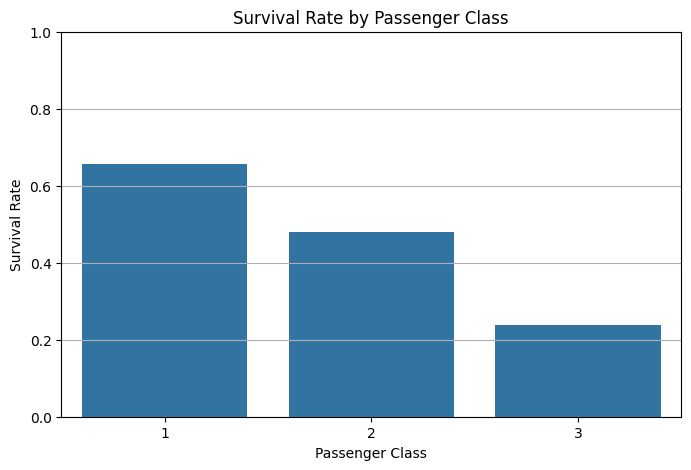

In [10]:
# Calculate survival rate by passenger class
survival_rate_by_pclass = df_cleaned_age.groupby('Pclass')['Survived'].mean().reset_index()

print("Survival rate by passenger class:")
display(survival_rate_by_pclass)

# Plot survival rate by passenger class
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=survival_rate_by_pclass)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.grid(axis='y')
plt.show()

Survival rate by Age Group:


/tmp/ipykernel_260/103016191.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned_age['AgeGroup'] = pd.cut(df_cleaned_age['Age'], bins=10)
/tmp/ipykernel_260/103016191.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_age_group = df_cleaned_age.groupby('AgeGroup')['Survived'].mean()


,Survived
AgeGroup,
"(0.34, 8.378]",0.666667
"(8.378, 16.336]",0.413043
"(16.336, 24.294]",0.355932
"(24.294, 32.252]",0.384615
"(32.252, 40.21]",0.440678
"(40.21, 48.168]",0.342857
"(48.168, 56.126]",0.466667
"(56.126, 64.084]",0.375000
"(64.084, 72.042]",0.000000


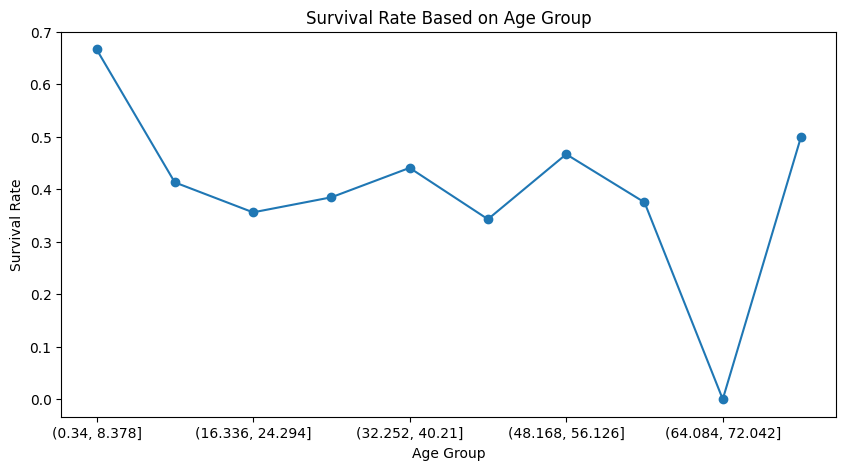

In [11]:
# Create age groups on the cleaned DataFrame
df_cleaned_age['AgeGroup'] = pd.cut(df_cleaned_age['Age'], bins=10)

# Calculate survival rate by AgeGroup
survival_rate_age_group = df_cleaned_age.groupby('AgeGroup')['Survived'].mean()

print("Survival rate by Age Group:")
display(survival_rate_age_group)

# Plot graph
plt.figure(figsize=(10,5))
survival_rate_age_group.plot(kind='line', marker='o')

plt.title("Survival Rate Based on Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()